## Question 12 — *What is the final state of tasks once they have been scheduled and executed on machines?*

Once the tasks have been scheduled and running, most of the tasks finish, while some of them are killed. Very few tasks fail or are evicted.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/14 23:27:58 WARN Utils: Your hostname, im2ag-mandelbrot, resolves to a loopback address: 127.0.1.1; using 152.77.81.20 instead (on interface ens18)
26/01/14 23:27:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/14 23:27:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/14 23:27:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.



Final distribution of task states (EVICT, FAIL, FINISH, KILL, LOST):


[(4, 127208), (5, 44796), (2, 6), (3, 815)]


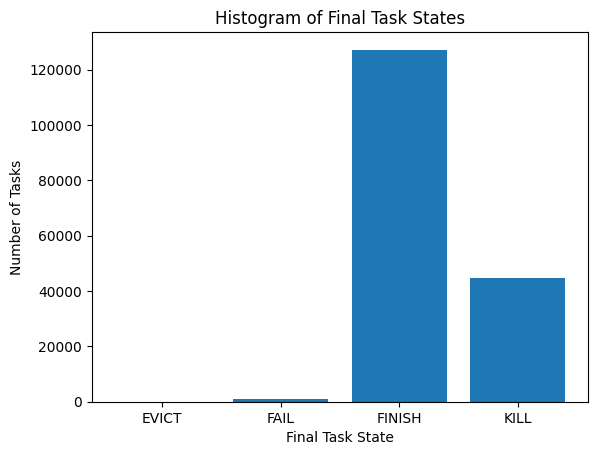

In [1]:
import sys
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

task_events_1 = sc.textFile("./data/task_events/part-00060-of-00500.csv.gz")
task_events_2 = sc.textFile("./data/task_events/part-00061-of-00500.csv.gz")
task_events_3 = sc.textFile("./data/task_events/part-00062-of-00500.csv.gz")
task_events_4 = sc.textFile("./data/task_events/part-00063-of-00500.csv.gz")
task_events_4 = sc.textFile("./data/task_events/part-00064-of-00500.csv.gz")

task_events_23_05 = (
    task_events_1.union(task_events_2).union(task_events_3).union(task_events_4)
    .map(lambda line: line.split(","))
    .map(lambda x: ( (x[2], x[3]), (int(x[0]), x[5]) )) # ( (job_id, task_idx), (timestamp, event_type) )
)

final_state_distribution = (
    task_events_23_05
    .reduceByKey(lambda a, b: a if a[0] > b[0] else b)   # keep last event
    .map(lambda x: int(x[1][1]))                         # event_type
    .filter(lambda e: e in [2, 3, 4, 5, 6])              # EVICT, FAIL, FINISH, KILL, LOST
    .map(lambda e: (e, 1))
    .reduceByKey(lambda a, b: a + b)
)

print("\n" + "="*80)
print("Final distribution of task states (EVICT, FAIL, FINISH, KILL, LOST):")
results = final_state_distribution.collect()
print(results)

# Plotting a histogram
results = sorted(results, key=lambda x: x[0])
labels = {
    2: "EVICT",
    3: "FAIL",
    4: "FINISH",
    5: "KILL",
    6: "LOST"
}

labels = [labels[e] for e, _ in results]
counts = [c for _, c in results]

plt.figure()
plt.bar(labels, counts)
plt.xlabel("Final Task State")
plt.ylabel("Number of Tasks")
plt.title("Histogram of Final Task States")
plt.show()

